In [1]:
import pandas as pd
import utils

from datetime import timedelta

from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')

# This script interpolates Snow Water Equivalent (SWE) data from CCI3-1, which is provided for every other day.
# It reads the SWE data from a CSV file, interpolates missing values,
# resamples the data, and saves the interpolated data to a new CSV file.

In [ ]:
# Path to the source SWE data CSV file
src_path = 'path/to/swe_cci3-1.csv'
data = utils.read_daily_timeseries_csv(src_path)
#Display original data
data

In [5]:
# Create a new index with daily frequency and reindex the data
orig_index = data.index
dest_index = pd.DatetimeIndex(pd.date_range(start=orig_index[0], end=orig_index[-1], freq='D'))
inter_data = pd.DataFrame(data, index=dest_index, columns=data.columns)
# Interpolate missing values
interpolated = inter_data.interpolate(axis=0, limit=3, limit_area='inside')
interpolated = interpolated.round(decimals=2)
# Save to new CSV
interpolated.to_csv('swe_cci3-1_inter.csv')

In [60]:
data_range=("1990", "2020") #data range for resampling

@FuncFormatter
def date_formatter(x, pos):
    time = pd.to_datetime(data_range[0]) + timedelta(days=x*4)
    label = f"{time.year}-{time.month}"
    return label

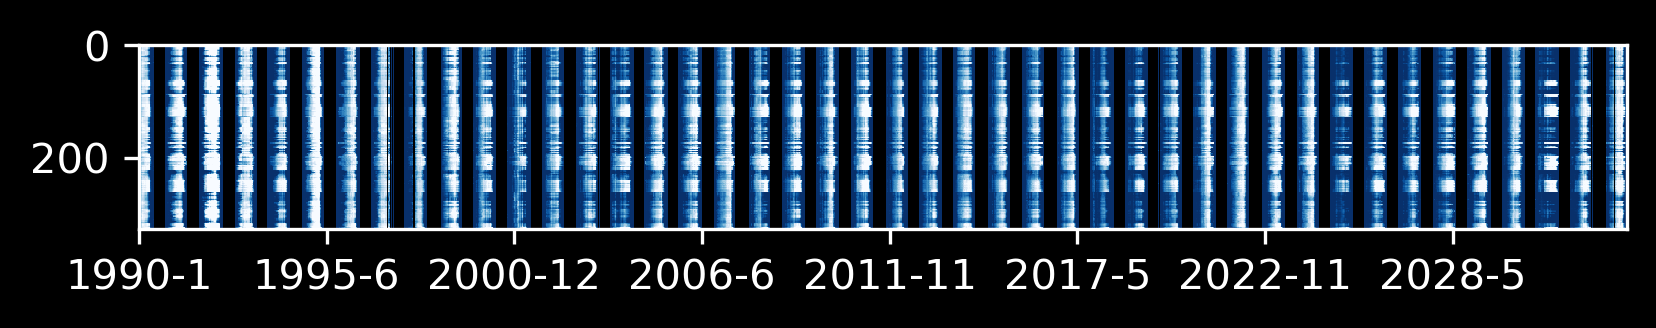

In [83]:
# 4-day mean
resampled_data = interpolated.resample('4D').mean()
resampled_data = resampled_data.transpose()

# Plot resampled data
fig, ax = plt.subplots()
imax = ax.imshow(resampled_data, cmap='Blues_r',vmax=150, aspect=1.5, interpolation='none')
ticks = ax.get_xticks()
ticks = ticks[1:-1]
labels = list(map(date_formatter, ticks))
result_ticks = ax.set_xticks(ticks, labels)